In [4]:
from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import QDDPM, WassDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'CIRCLEY',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers = 1000, 2, 40, 2, 6
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'
device = 'cpu'

/tmp/ipykernel_1874505/4126801994.py:4: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  cols = np.int(np.ceil(n_timesteps/rows))


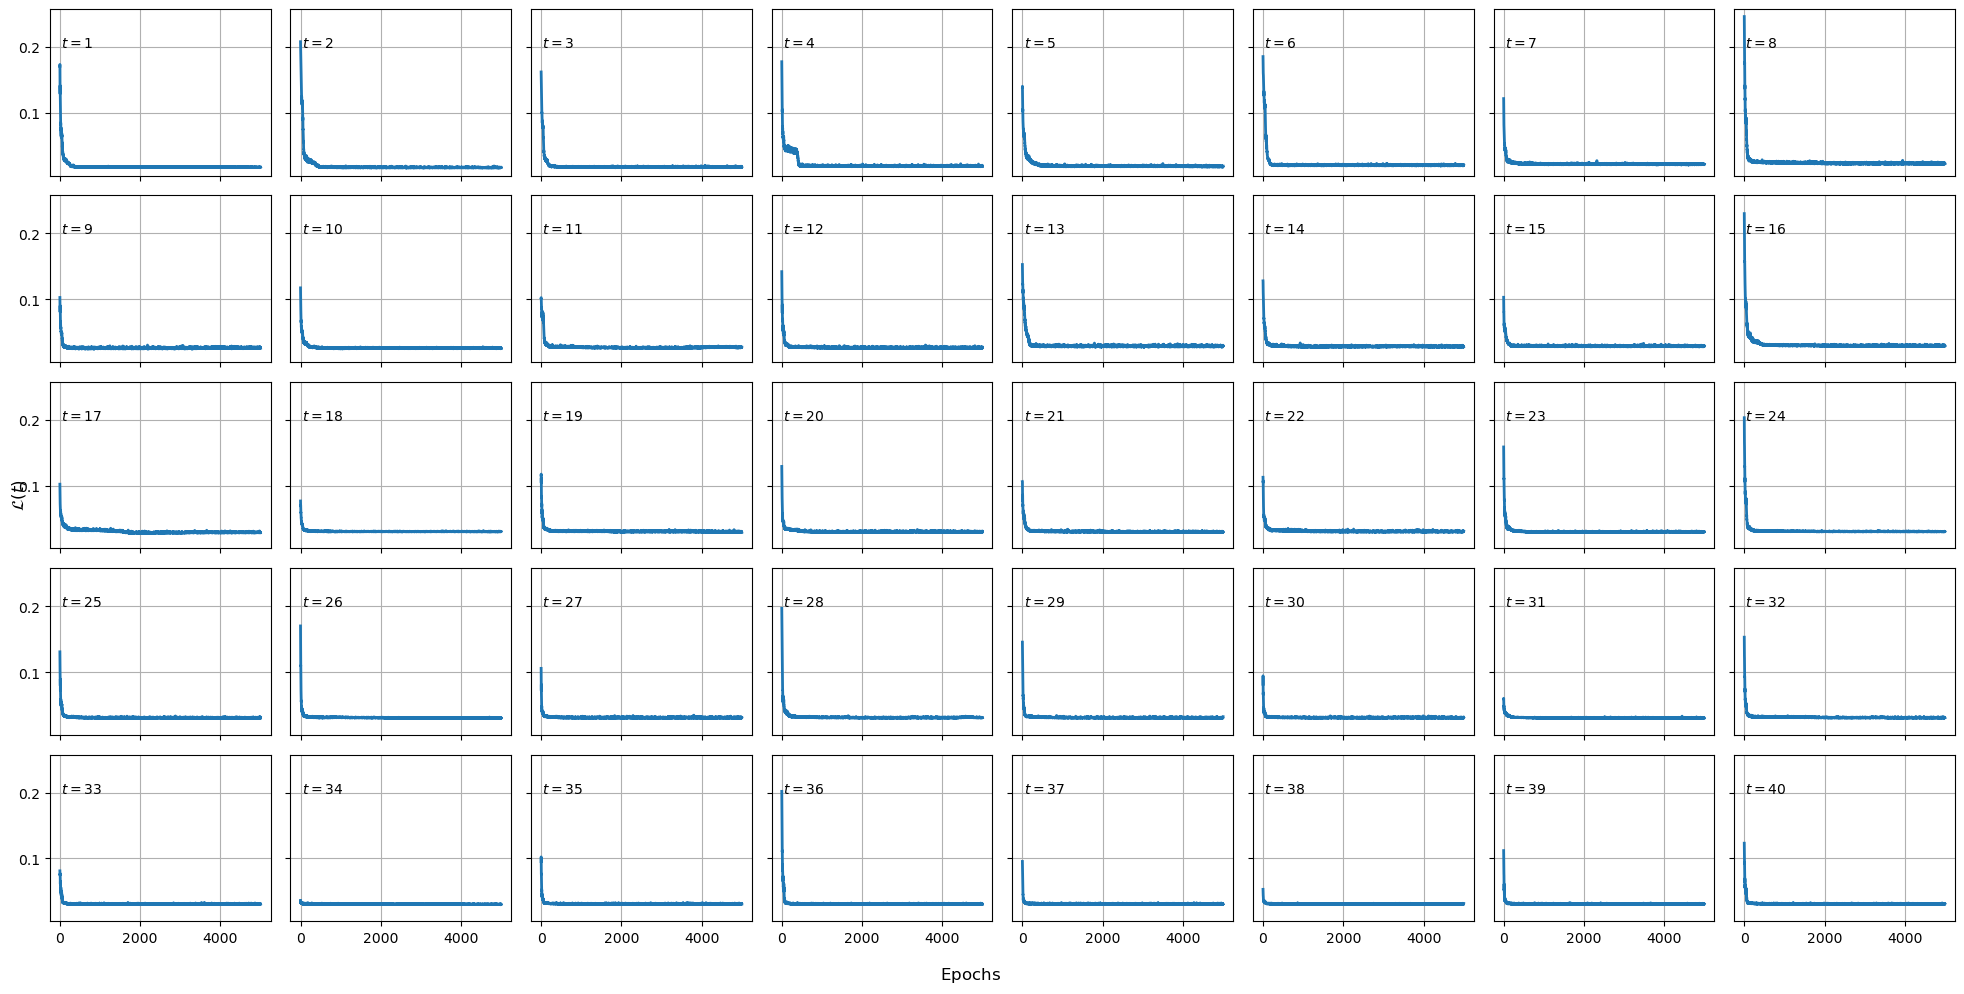

In [17]:
size = 10

rows = 5
cols = np.int(np.ceil(n_timesteps/rows))
fig, axs = plt.subplots(rows, cols, figsize=(size+10, size), sharex=True, sharey=True)
for i in range(n_timesteps):
    # if i < 11:
    #     continue
    dir, filename = get_path(config, type='modelfinallosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=i+1)
    loss = np.load(dir / filename)
    axs[i//cols, i%cols].plot(loss, lw=2)
    # axs[i//5, i%5].tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=20)
    axs[i//cols, i%cols].text(x=30, y=0.2, s=r'$t=%d$'%(i+1), fontsize=10)
    # axs[i//5, i%5].set_yscale('log')
    axs[i//cols, i%cols].grid(True)
fig.supxlabel(r'$\rm Epochs$')
fig.supylabel(r'$\mathcal{L}(t)$')
plt.tight_layout()

In [16]:
# # Compute Wasserstein distance across timesteps
# wassbackwardtrain = np.zeros(n_timesteps)
# for i in range(n_timesteps):
#     dir, filename = get_path(config, type='modellosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=i+1)
#     loss = np.load(dir / filename)

#     wassbackwardtrain[i] = loss[-1]

# # Backward training (last element of the loss history of each timestep)

In [9]:
# Compute Wasserstein distance across timesteps
device = torch.device('cpu')
torch.set_default_device(device)

dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
states_diffused = torch.from_numpy(np.load(dir / filename)).to(device)
state_0 = states_diffused[0]

# Load the parameters, sample using the model and compute the images
params_tot = torch.zeros((n_timesteps, 2*(n_qubits+n_ancilla_qubits)*n_backward_layers), device=device)
for tt in range(1, n_timesteps+1):
    dir, filename = get_path(config, type='modelparams', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=tt)
    params_tot[tt-1] = torch.from_numpy(np.load(dir / filename)).to(device)

# Inference using the model
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)
inputs_last_timestep = states_diffused[-1]
outputs = torch.zeros((n_timesteps+1, n_data, 2**(n_qubits)), device=device, dtype=torch.complex64)
outputs[-1] = inputs_last_timestep
inputs = torch.zeros((n_timesteps, n_data, 2**(n_qubits+n_ancilla_qubits)), device=device, dtype=torch.complex64)
for t in tqdm(range(n_timesteps, 0, -1)):
    inputs[t-1, :, :2**n_qubits] = outputs[t]
    outputs[t-1] = model.backwardOutput_t(inputs[t-1], params_tot[t-1])

    # input_tplus1 = model.prepareInput_t(inputs_last_timestep, params_tot, t, n_data)
    # outputs[t-1] = model.backwardOutput_t(input_tplus1, params_tot[t-1])
# Lo que cuesta es el prepareInput_t lol.

100%|██████████| 40/40 [00:06<00:00,  5.71it/s]


In [10]:
# Compute the Wasserstein Distance
wass = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps+1)):
    np.random.seed()
    wass[t] = WassDistance(states_diffused[0], outputs[t]).detach().cpu().numpy()

dir, filename = get_path(config, type='wassdistbackwardtrain', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
np.save(dir / filename, wass)

# Now of the forward pass
# Wasserstein distance
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
diffused_states = torch.from_numpy(np.load(dir / filename))

wass = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps+1)):
    np.random.seed()
    wass[t] = WassDistance(diffused_states[0], diffused_states[t]).detach().numpy()

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_timesteps=n_timesteps)
np.save(dir / filename, wass)

100%|██████████| 41/41 [00:13<00:00,  3.02it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward and backward processes')

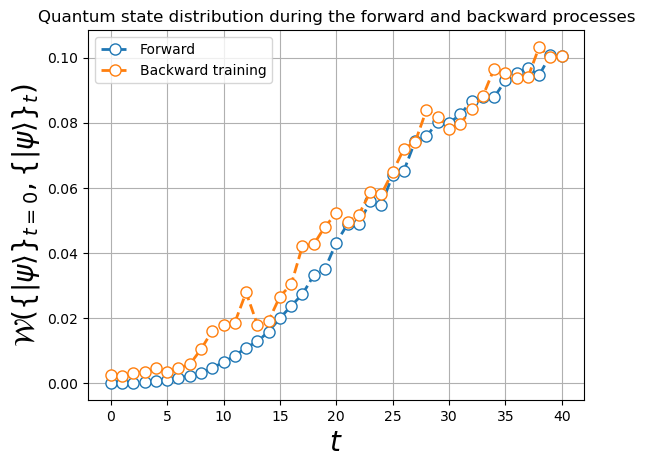

In [11]:
# Plot it

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
wassforward = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistbackwardtrain', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
wassbackwardtrain = np.load(dir / filename)

plt.plot(wassforward, 'o--', label='Forward', mfc='white', markersize=8, lw=2)
plt.plot(wassbackwardtrain, 'o--', label='Backward training', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
plt.grid(True)
plt.legend()
plt.title(f'Quantum state distribution during the forward and backward processes')

In [19]:
# Compute the images across timesteps.
# device = torch.device('cuda:0')
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)

# Load just one corrupted state
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits,n_timesteps=n_timesteps)
states_diffused = np.load(dir / filename)
diffused_state = states_diffused[-1, 0] # Last timestep, first sample


# Load the parameters, sample using the model and compute the images

params_tot = torch.zeros((n_timesteps, 2*(n_qubits+n_ancilla_qubits)*n_backward_layers), device=device)
for tt in range(1, n_timesteps+1):
    dir, filename = get_path(config, type='modelparams', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=tt)
    params_tot[tt-1] = torch.from_numpy(np.load(dir / filename)).to(device)

inputs_last_timestep = torch.from_numpy(states_diffused[-1]).to(device)

# Inference using the model
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)
inputs_last_timestep = torch.from_numpy(states_diffused[-1]).to(device)
outputs = torch.zeros((n_timesteps+1, n_data, 2**(n_qubits)), device=device, dtype=torch.complex64)
outputs[-1] = inputs_last_timestep
inputs = torch.zeros((n_timesteps, n_data, 2**(n_qubits+n_ancilla_qubits)), device=device, dtype=torch.complex64)
for t in tqdm(range(n_timesteps, 0, -1)):
    inputs[t-1, :, :2**n_qubits] = outputs[t]
    outputs[t-1] = model.backwardOutput_t(inputs[t-1], params_tot[t-1])

100%|██████████| 40/40 [00:04<00:00,  9.93it/s]


  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:00<00:00, 1794.05it/s]


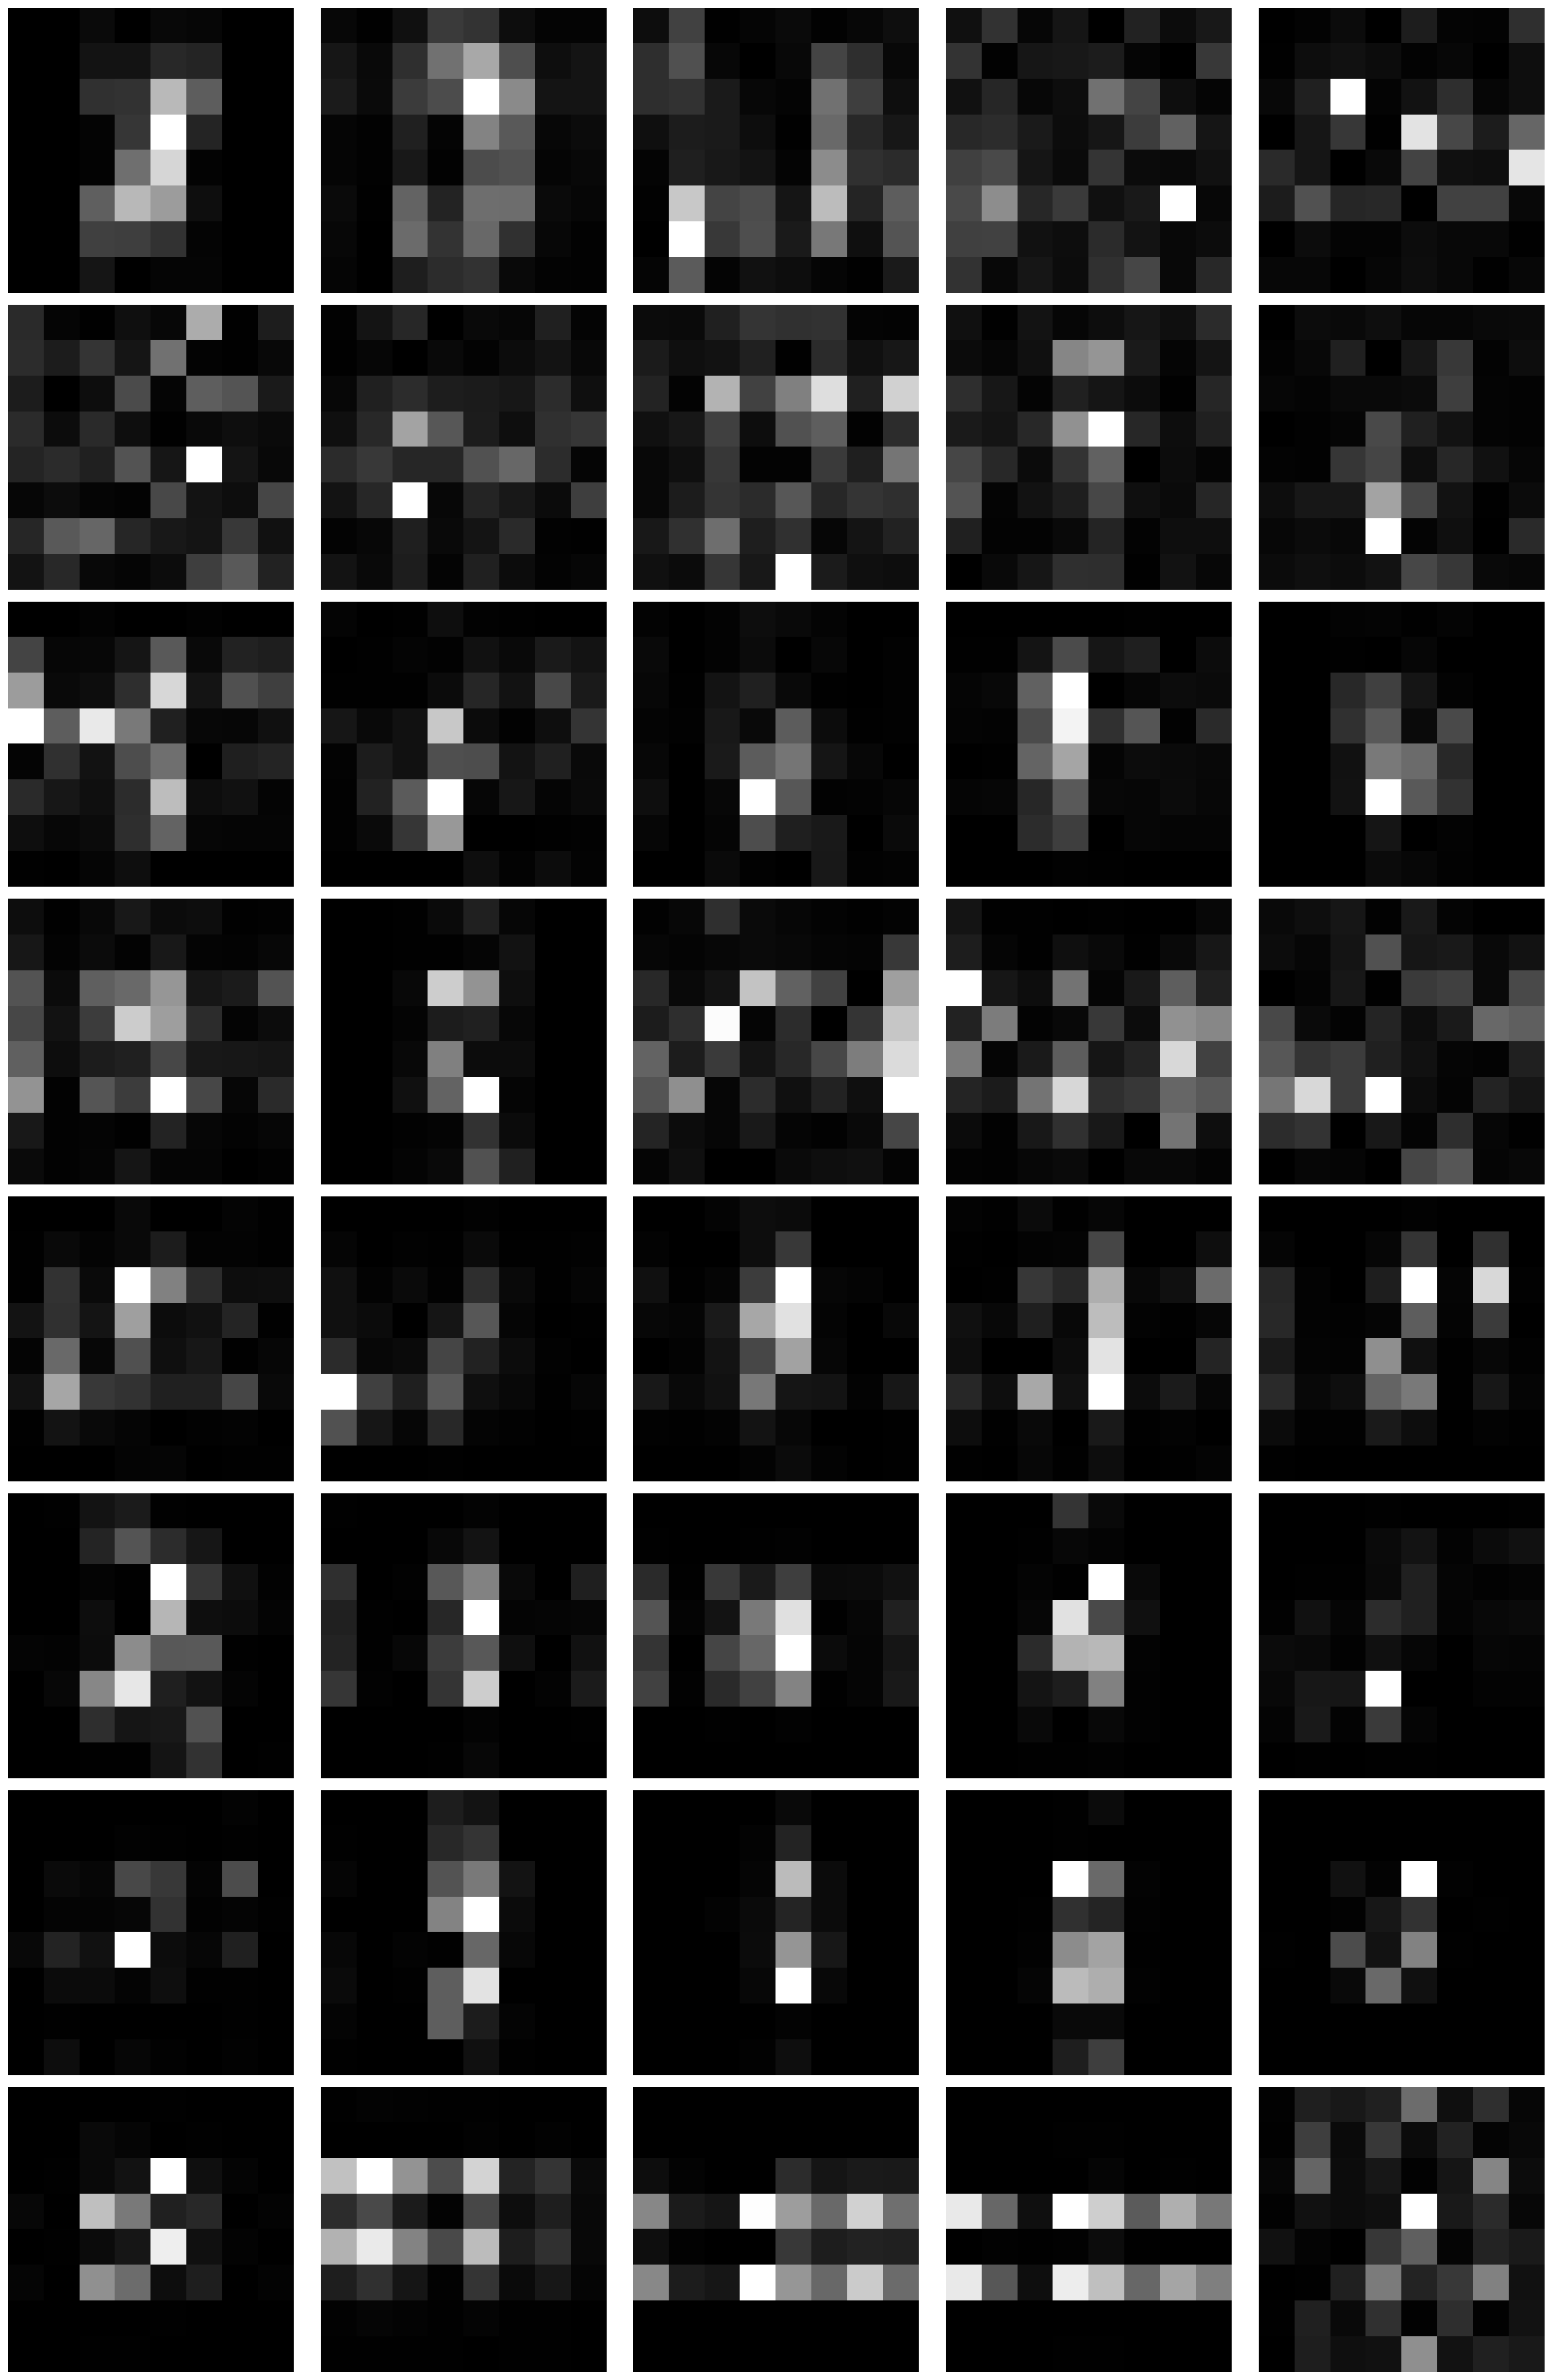

In [27]:
# Visualize the evolution of one image
n = 3 # select a sample

image_dim = int(np.sqrt(n_pixels))
rows = 8
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(20,30))
vmin, vmax = 0, 1
images = []
for i in tqdm(range(n_timesteps+1)):
    if i == n_timesteps:
        continue
    # Extract the probabilities and convert back to MNIST digits
    state = outputs[i, n].detach().cpu().numpy()
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_pixels]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1]
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i//cols, i%cols].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i//cols, i%cols].axis('off')

plt.tight_layout()

(-0.5, 7.5, 7.5, -0.5)

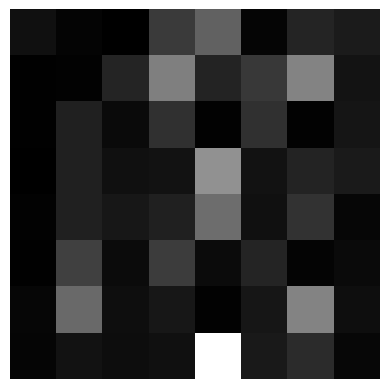

In [28]:
# The last step (full noise)
i = n_timesteps
state = outputs[i, n]
probs = (state*state.conj()).real
probs = probs[:, np.newaxis][:n_pixels]
image = probs.reshape(image_dim, image_dim)

norm = 1 / image.max()
image = image * norm

images.append(image)

plt.imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
plt.axis('off')